#### Project Summary - Home Loan Prediction
This project helps build a deeper understanding of classification problems with an imbalanced dataset. The objective is to create a model that predicts whether an applicant will be able to repay a loan using historical data.

Domain: Finance

I am using the [HMEQ dataset](https://www.kaggle.com/datasets/ajay1735/hmeq-data?resource=download) downloaded from Kaggle. This is a binary classification problem with a roughly 80/20 class imbalance. An Artificial Neural Network (ANN) model will be trained to make the predictions and will be compared against a baseline model. 

## Imports

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import warnings
warnings.filterwarnings("ignore")

# Core
import numpy as np
import pandas as pd
from pathlib import Path
import random

# Train/Test Split, Scaling, Encoding, Imputation
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Class Imbalance
from sklearn.utils.class_weight import compute_class_weight

# Baseline Model
from sklearn.linear_model import LogisticRegression

# Deep Learning
import tensorflow as tf
import keras
from keras import layers
from keras.callbacks import EarlyStopping
from keras.layers import Dropout, BatchNormalization

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# Visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## Loading Data

In [2]:
DATA_PATH = Path('../data/raw/hmeq.csv')
df = pd.read_csv(DATA_PATH).copy()

df.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [3]:
# General Inspection
df.info()
print('Shape of the dataset:', df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   str    
 5   JOB      5681 non-null   str    
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), str(2)
memory usage: 605.4 KB
Shape of the dataset: (5960, 13)


## Data Preprocessing

In [4]:
# Checking Missing Values and Duplicates
print('Missing values per column:\n')
print(df.isnull().sum())
print('\nNumber of duplicate rows:', df.duplicated().sum())

Missing values per column:

BAD           0
LOAN          0
MORTDUE     518
VALUE       112
REASON      252
JOB         279
YOJ         515
DEROG       708
DELINQ      580
CLAGE       308
NINQ        510
CLNO        222
DEBTINC    1267
dtype: int64

Number of duplicate rows: 0


## EDA

Class Counts:
BAD
0    4771
1    1189
Name: count, dtype: int64

Class Percentages:
BAD
0    80.05
1    19.95
Name: proportion, dtype: float64


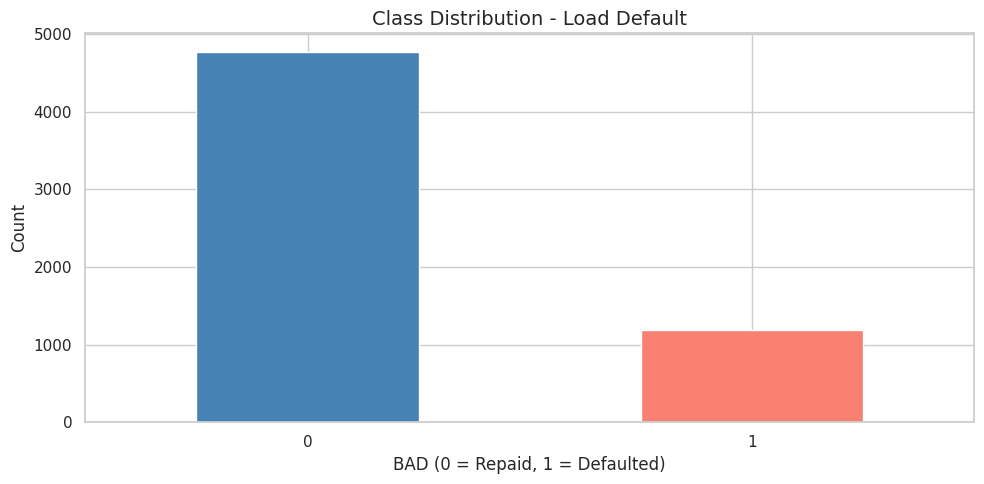

In [5]:
# Bar Plot Of Class Distribution
counts = df["BAD"].value_counts().sort_index()
percentages = target_counts = df['BAD'].value_counts(normalize=True).sort_index() * 100


print("Class Counts:")
print(counts)
print("\nClass Percentages:")
print(percentages.round(2))

counts.plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Class Distribution - Load Default')
plt.xlabel('BAD (0 = Repaid, 1 = Defaulted)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

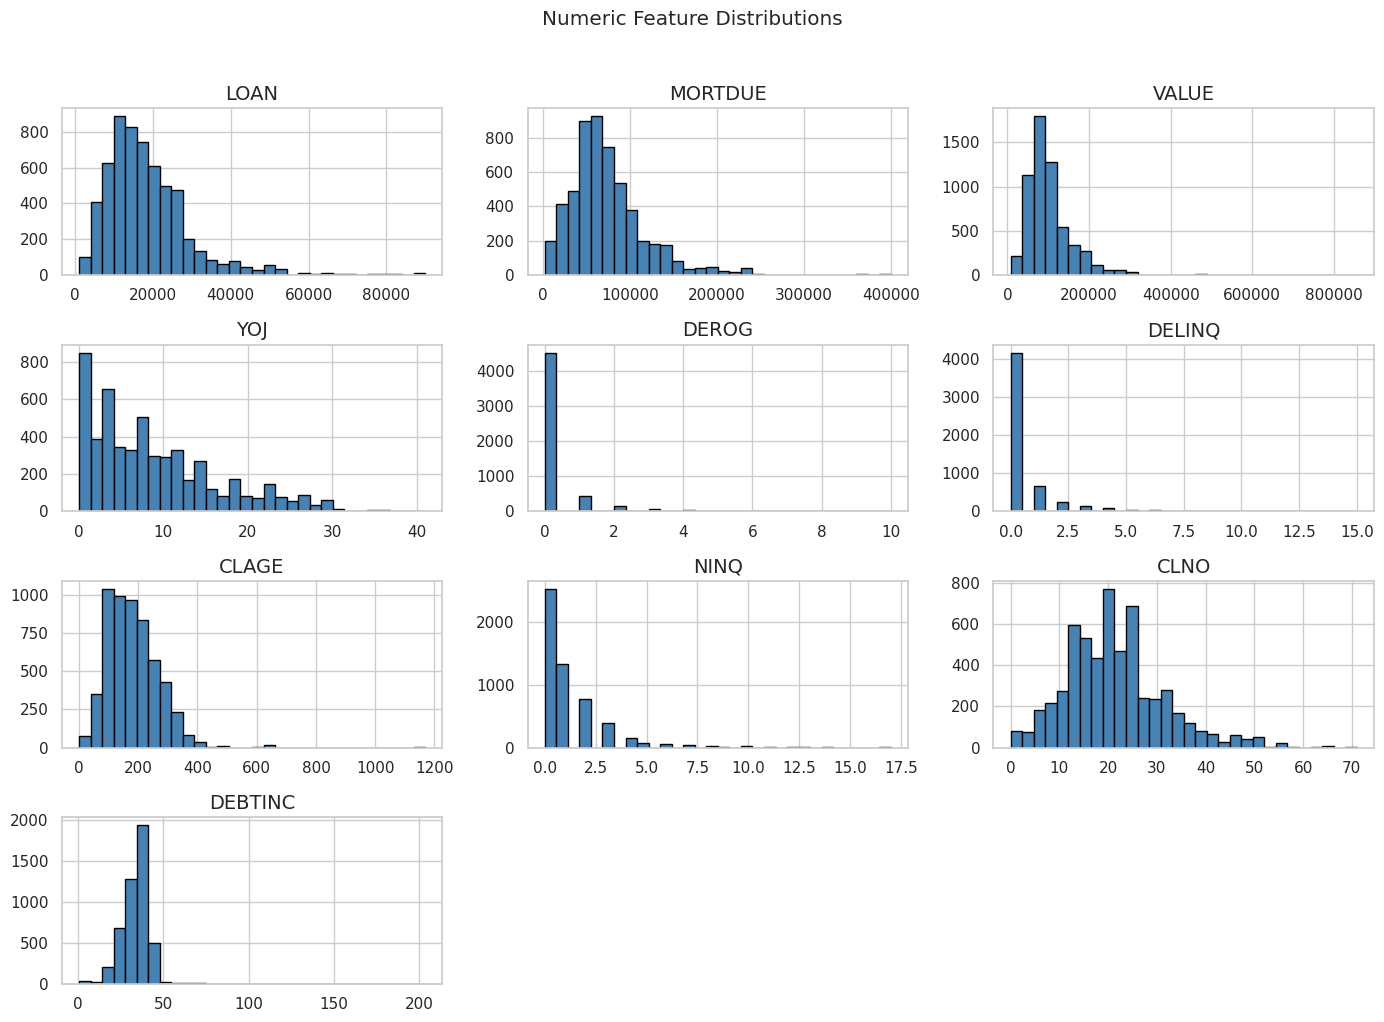

In [6]:
# Numeric Feature Distribution
num_cols = df.select_dtypes(include=['int64', 'float64']).drop(columns=['BAD']).columns

df[num_cols].hist(bins=30, figsize=(14, 10), color='steelblue', edgecolor='black')
plt.suptitle('Numeric Feature Distributions', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

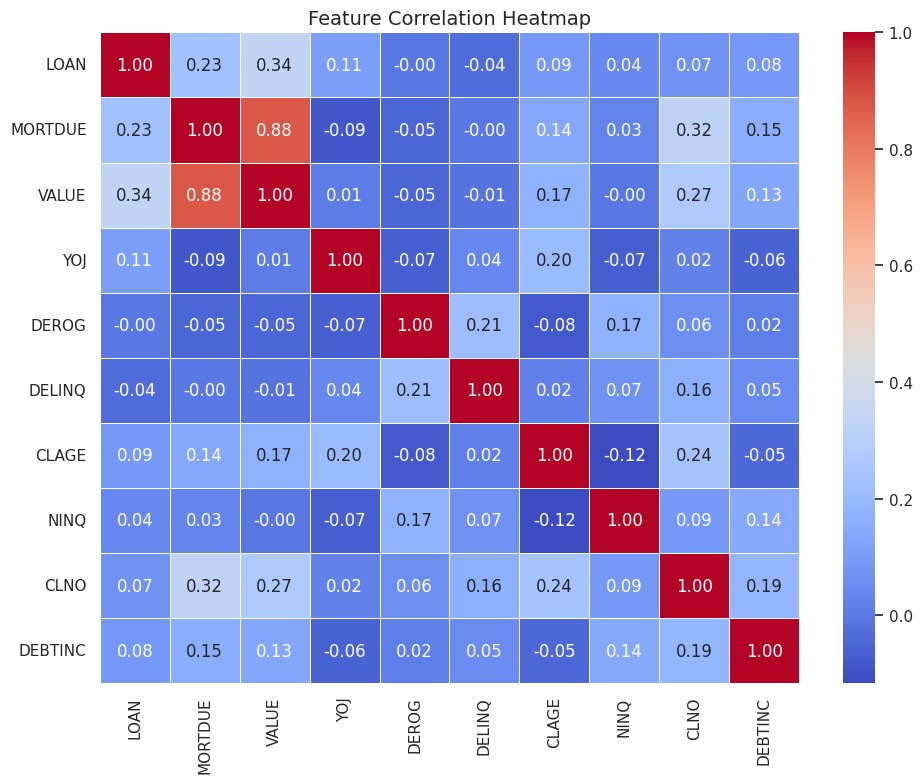

In [7]:
# Correlation Heatmap

plt.figure(figsize=(10, 8))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

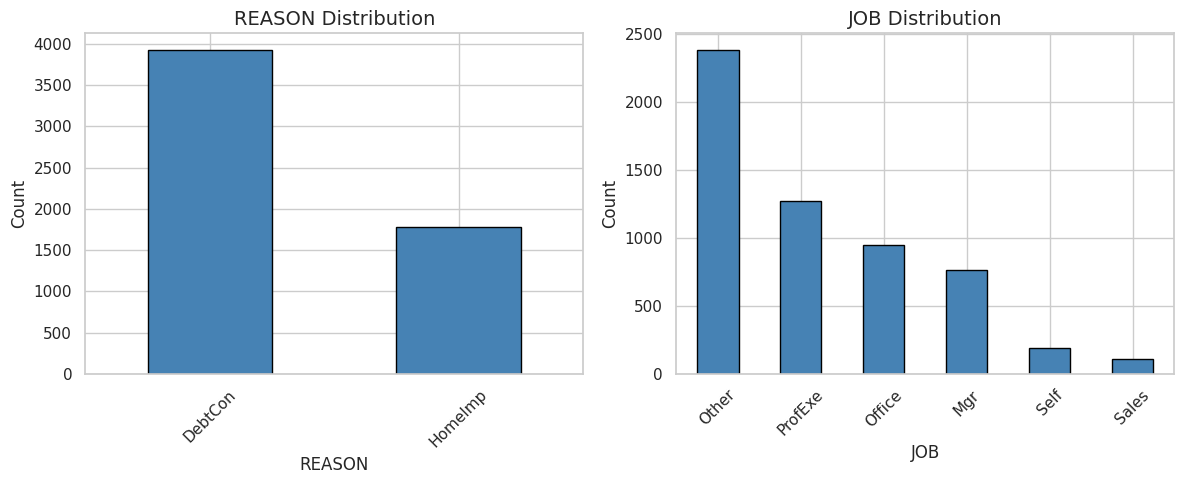

In [8]:
# Categorical Feature Distributions

cat_cols = df.select_dtypes(include=['object']).columns

fig, axes = plt.subplots(1, len(cat_cols), figsize=(12, 5))

for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/figures/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Report

In [9]:
# Generate report text
report = f"""
Date: {pd.Timestamp.now().strftime('%B %d, %Y')}
Dataset: HMEQ Home Equity Loan Default Dataset
Records Analyzed: {len(df):,}
---------------------------------------------------------------------------------------------------------

** EDA FINDINGS **


1) CLASS DISTRIBUTION

The dataset is imbalanced with roughly 80% non-default and 20% default cases.
Accuracy alone is not a reliable metric here. Precision, recall, and AUC-ROC
will be used for evaluation.


2) FEATURE DISTRIBUTIONS

Most numeric features are right-skewed with high-value outliers. DEROG and
DELINQ are zero-inflated. Most applicants have clean credit histories, but
elevated values in these columns are likely strong default indicators.


3) CORRELATIONS

MORTDUE and VALUE have the strongest correlation. This is expected since larger
properties carry larger mortgages. LOAN and CLNO also show moderate correlation.
No features were dropped as a result.


4) MISSING DATA

Missing values were imputed instead of dropped to preserve dataset size. DEBTINC
had the highest missing rate at around 21%. Numeric features were imputed with
the median and categorical features with the most frequent value.


5) CATEGORICAL FEATURES

Most loan requests are for debt consolidation. Home improvement is the secondary
reason. The most common job categories are Other and Professional.

"""


with open("../outputs/reports/home_loan_report.txt", "w") as f:
    f.write(report)

print("Report Saved")


Report Saved


## Train-Test Split

In [10]:
# Defining Features and Target
X = df.drop(columns=['BAD'])
y = df['BAD']


X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3, 
    random_state=SEED, 
    stratify=y
)


X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.5, 
    random_state=SEED, 
    stratify=y_temp
)

y_train = y_train.astype(int)
y_test = y_test.astype(int)
y_val = y_val.astype(int)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train defaults: {y_train.value_counts().get(1, 0)}")
print(f"Val defaults: {y_val.value_counts().get(1, 0)}")
print(f"Test defaults: {y_test.value_counts().get(1, 0)}")

Train: (4172, 12), Val: (894, 12), Test: (894, 12)
Train defaults: 832
Val defaults: 178
Test defaults: 179


## Computing Class Weights 

In [11]:
ClassWeights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(zip(np.unique(y_train), ClassWeights))
print(class_weights)

{np.int64(0): np.float64(0.6245508982035928), np.int64(1): np.float64(2.5072115384615383)}


## Preprocessing Pipeline (Scaling, Encoding, Imputation)

In [12]:
# Preprocessing Pipeline

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category', 'str']).columns

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, num_cols),
        ('cat', categorical_pipeline, cat_cols)
    ],
    remainder='drop'
)


X_train_processed = preprocessor.fit_transform(X_train).astype(np.float32)
X_test_processed = preprocessor.transform(X_test).astype(np.float32)
X_val_processed = preprocessor.transform(X_val).astype(np.float32)

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)
print("Processed val shape:", X_val_processed.shape)

Numeric columns: 10
Categorical columns: 2
Processed train shape: (4172, 18)
Processed test shape: (894, 18)
Processed val shape: (894, 18)


## Training Baseline Model

In [13]:
# Baseline Model — Logistic Regression

lr = LogisticRegression(class_weight='balanced', random_state=SEED, max_iter=1000)
lr.fit(X_train_processed, y_train)

y_pred_lr = lr.predict(X_test_processed)
y_proba_lr = lr.predict_proba(X_test_processed)[:, 1]

print("Baseline — Logistic Regression")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Baseline — Logistic Regression
Accuracy: 0.7673
ROC-AUC: 0.7707

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.80      0.85       715
           1       0.44      0.64      0.53       179

    accuracy                           0.77       894
   macro avg       0.67      0.72      0.69       894
weighted avg       0.81      0.77      0.78       894



## Training ANN Model

In [14]:
# Building the Deep Learning Model

model = keras.Sequential([
    layers.Input(shape=(X_train_processed.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])

# Compiling the Model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')])


# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=5,
        restore_best_weights=True,
        mode='max'
    )
]

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Fitting the Model
history = model.fit(
    X_train_processed, y_train,
    validation_data=(X_val_processed, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.4763 - auc: 0.4620 - loss: 0.7260 - val_accuracy: 0.4206 - val_auc: 0.5346 - val_loss: 0.7078
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4796 - auc: 0.5333 - loss: 0.6970 - val_accuracy: 0.4407 - val_auc: 0.6510 - val_loss: 0.6994
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5012 - auc: 0.5864 - loss: 0.6753 - val_accuracy: 0.4810 - val_auc: 0.7183 - val_loss: 0.6888
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5338 - auc: 0.6447 - loss: 0.6559 - val_accuracy: 0.5694 - val_auc: 0.7550 - val_loss: 0.6760
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5765 - auc: 0.6805 - loss: 0.6443 - val_accuracy: 0.6286 - val_auc: 0.7738 - val_loss: 0.6609
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6210 - auc: 0.7158 - loss: 0.6268 - val_accuracy: 0.6834 - val_auc: 0.7850 - val_loss: 0.6436
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━

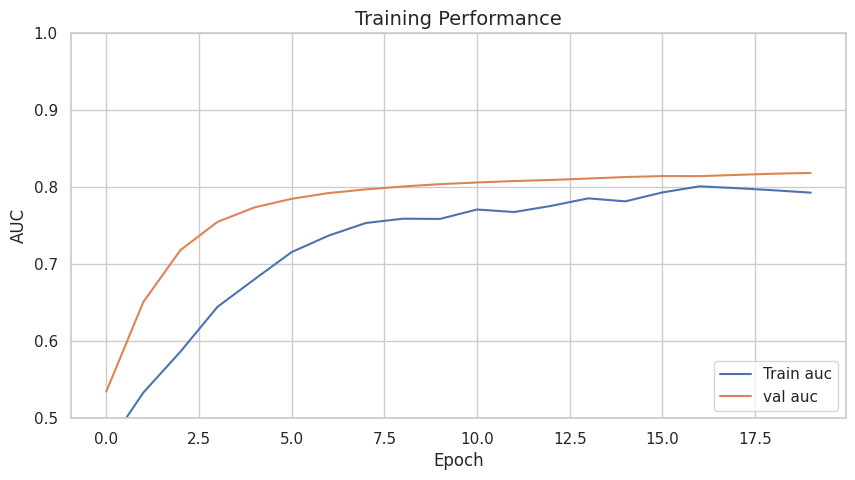

In [16]:
# Visualizing Training Performance
plt.plot(history.history['auc'], label='Train auc')
plt.plot(history.history['val_auc'], label = 'val auc')
plt.title('Training Performance')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

## Evaluation & Prediction

In [21]:
y_probs = model.predict(X_test_processed).ravel()
y_pred = (y_probs >= optimal_threshold).astype(int)


print("ANN - Deep Learning Model")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
ANN - Deep Learning Model
Accuracy: 0.7629
ROC-AUC: 0.7946

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       715
           1       0.44      0.70      0.54       179

    accuracy                           0.76       894
   macro avg       0.68      0.74      0.69       894
weighted avg       0.82      0.76      0.78       894



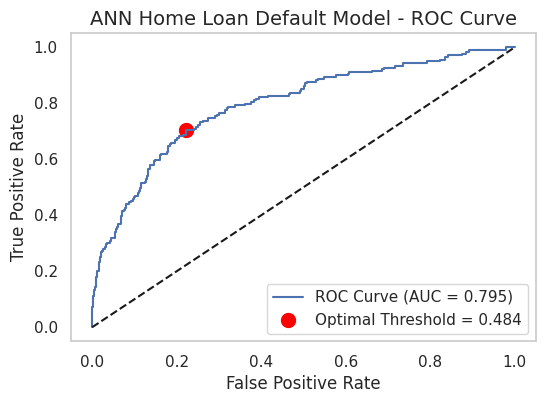

In [23]:
# Plottng ROC Curve

# ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# Find optimal threshold using Youden's J statistic
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]



# ROC Curve Plot
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--')


plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100, label=f'Optimal Threshold = {optimal_threshold:.3f}')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ANN Home Loan Default Model - ROC Curve")
plt.legend(loc='lower right')
plt.grid()
plt.show()